# Импорты и вспомогательные функции.

In [ ]:
# ## Установка библиотек
# !pip install scikit-learn -q
# !pip install statsmodels -q
# !pip install seaborn -q

In [ ]:
## Импорт библиотек
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Вспомогательные функции
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
import pandas as pd # Ensure pandas is imported for DataFrame creation

def print_classification_metrics(model, X_test, y_test, model_name):
    """Calculates and prints evaluation metrics and confusion matrix for a given classification model."""
    metrics_df = get_classification_metrics(model, X_test, y_test, model_name)
    print(f"Metrics for {model_name}:")
    for col in metrics_df.columns:
        if col != 'model_nm':
            print(f"{col}: {metrics_df[col].iloc[0]}")
    print("\n") # Add a newline for better readability

def get_classification_metrics(model, X_test, y_test, model_name):
    """Calculates evaluation metrics for classification models and returns them as a pandas DataFrame."""
    y_pred = model.predict(X_test)

    metrics = {'model_nm': model_name}

    metrics['Accuracy'] = round(accuracy_score(y_test, y_pred), 4)
    metrics['Precision'] = round(precision_score(y_test, y_pred), 4)
    metrics['Recall'] = round(recall_score(y_test, y_pred), 4)

    # Check if the model has predict_proba, essential for AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        metrics['AUC'] = round(roc_auc_score(y_test, y_proba), 4)
    else:
        metrics['AUC'] = 'N/A' # Indicate AUC is not applicable

    cm = confusion_matrix(y_test, y_pred)
    # Storing confusion matrix as a string representation or list of lists
    metrics['Confusion_Matrix'] = str(cm.tolist()) # Store as a string representation of list of lists

    return pd.DataFrame([metrics])

def print_regression_metrics(model, X_test, y_test, model_name):
    """Calculates and prints evaluation metrics for a given regression model."""
    metrics_df = get_regression_metrics(model, X_test, y_test, model_name)
    print(f"Metrics for {model_name}:")
    for col in metrics_df.columns:
        if col != 'model_nm':
            print(f"{col}: {metrics_df[col].iloc[0]}")
    print("\n") # Add a newline for better readability

def get_regression_metrics(model, X_test, y_test, model_name):
    """Calculates evaluation metrics for regression models and returns them as a pandas DataFrame."""
    # For statsmodels, prediction needs to be called on the model directly
    if hasattr(model, 'predict'):
        y_pred = model.predict(X_test)
    elif hasattr(model, 'model'): # For models wrapped by sklearn like Lasso/Ridge
        y_pred = model.model.predict(X_test)
    else:
        raise ValueError("Model does not have a predict method.")

    metrics = {'model_nm': model_name}
    metrics['MSE'] = round(mean_squared_error(y_test, y_pred), 4)
    metrics['R2_Score'] = round(r2_score(y_test, y_pred), 4)
    metrics['MAE'] = round(mean_absolute_error(y_test, y_pred), 4)

    return pd.DataFrame([metrics])

# Задача Регрессии

In [ ]:
import pandas as pd

# Load the red wine quality dataset
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## EDA

In [ ]:
# Описание датафрейма
data.info()

# Статистические характеристики
data.describe()

# Проверка на пропущенные значения
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


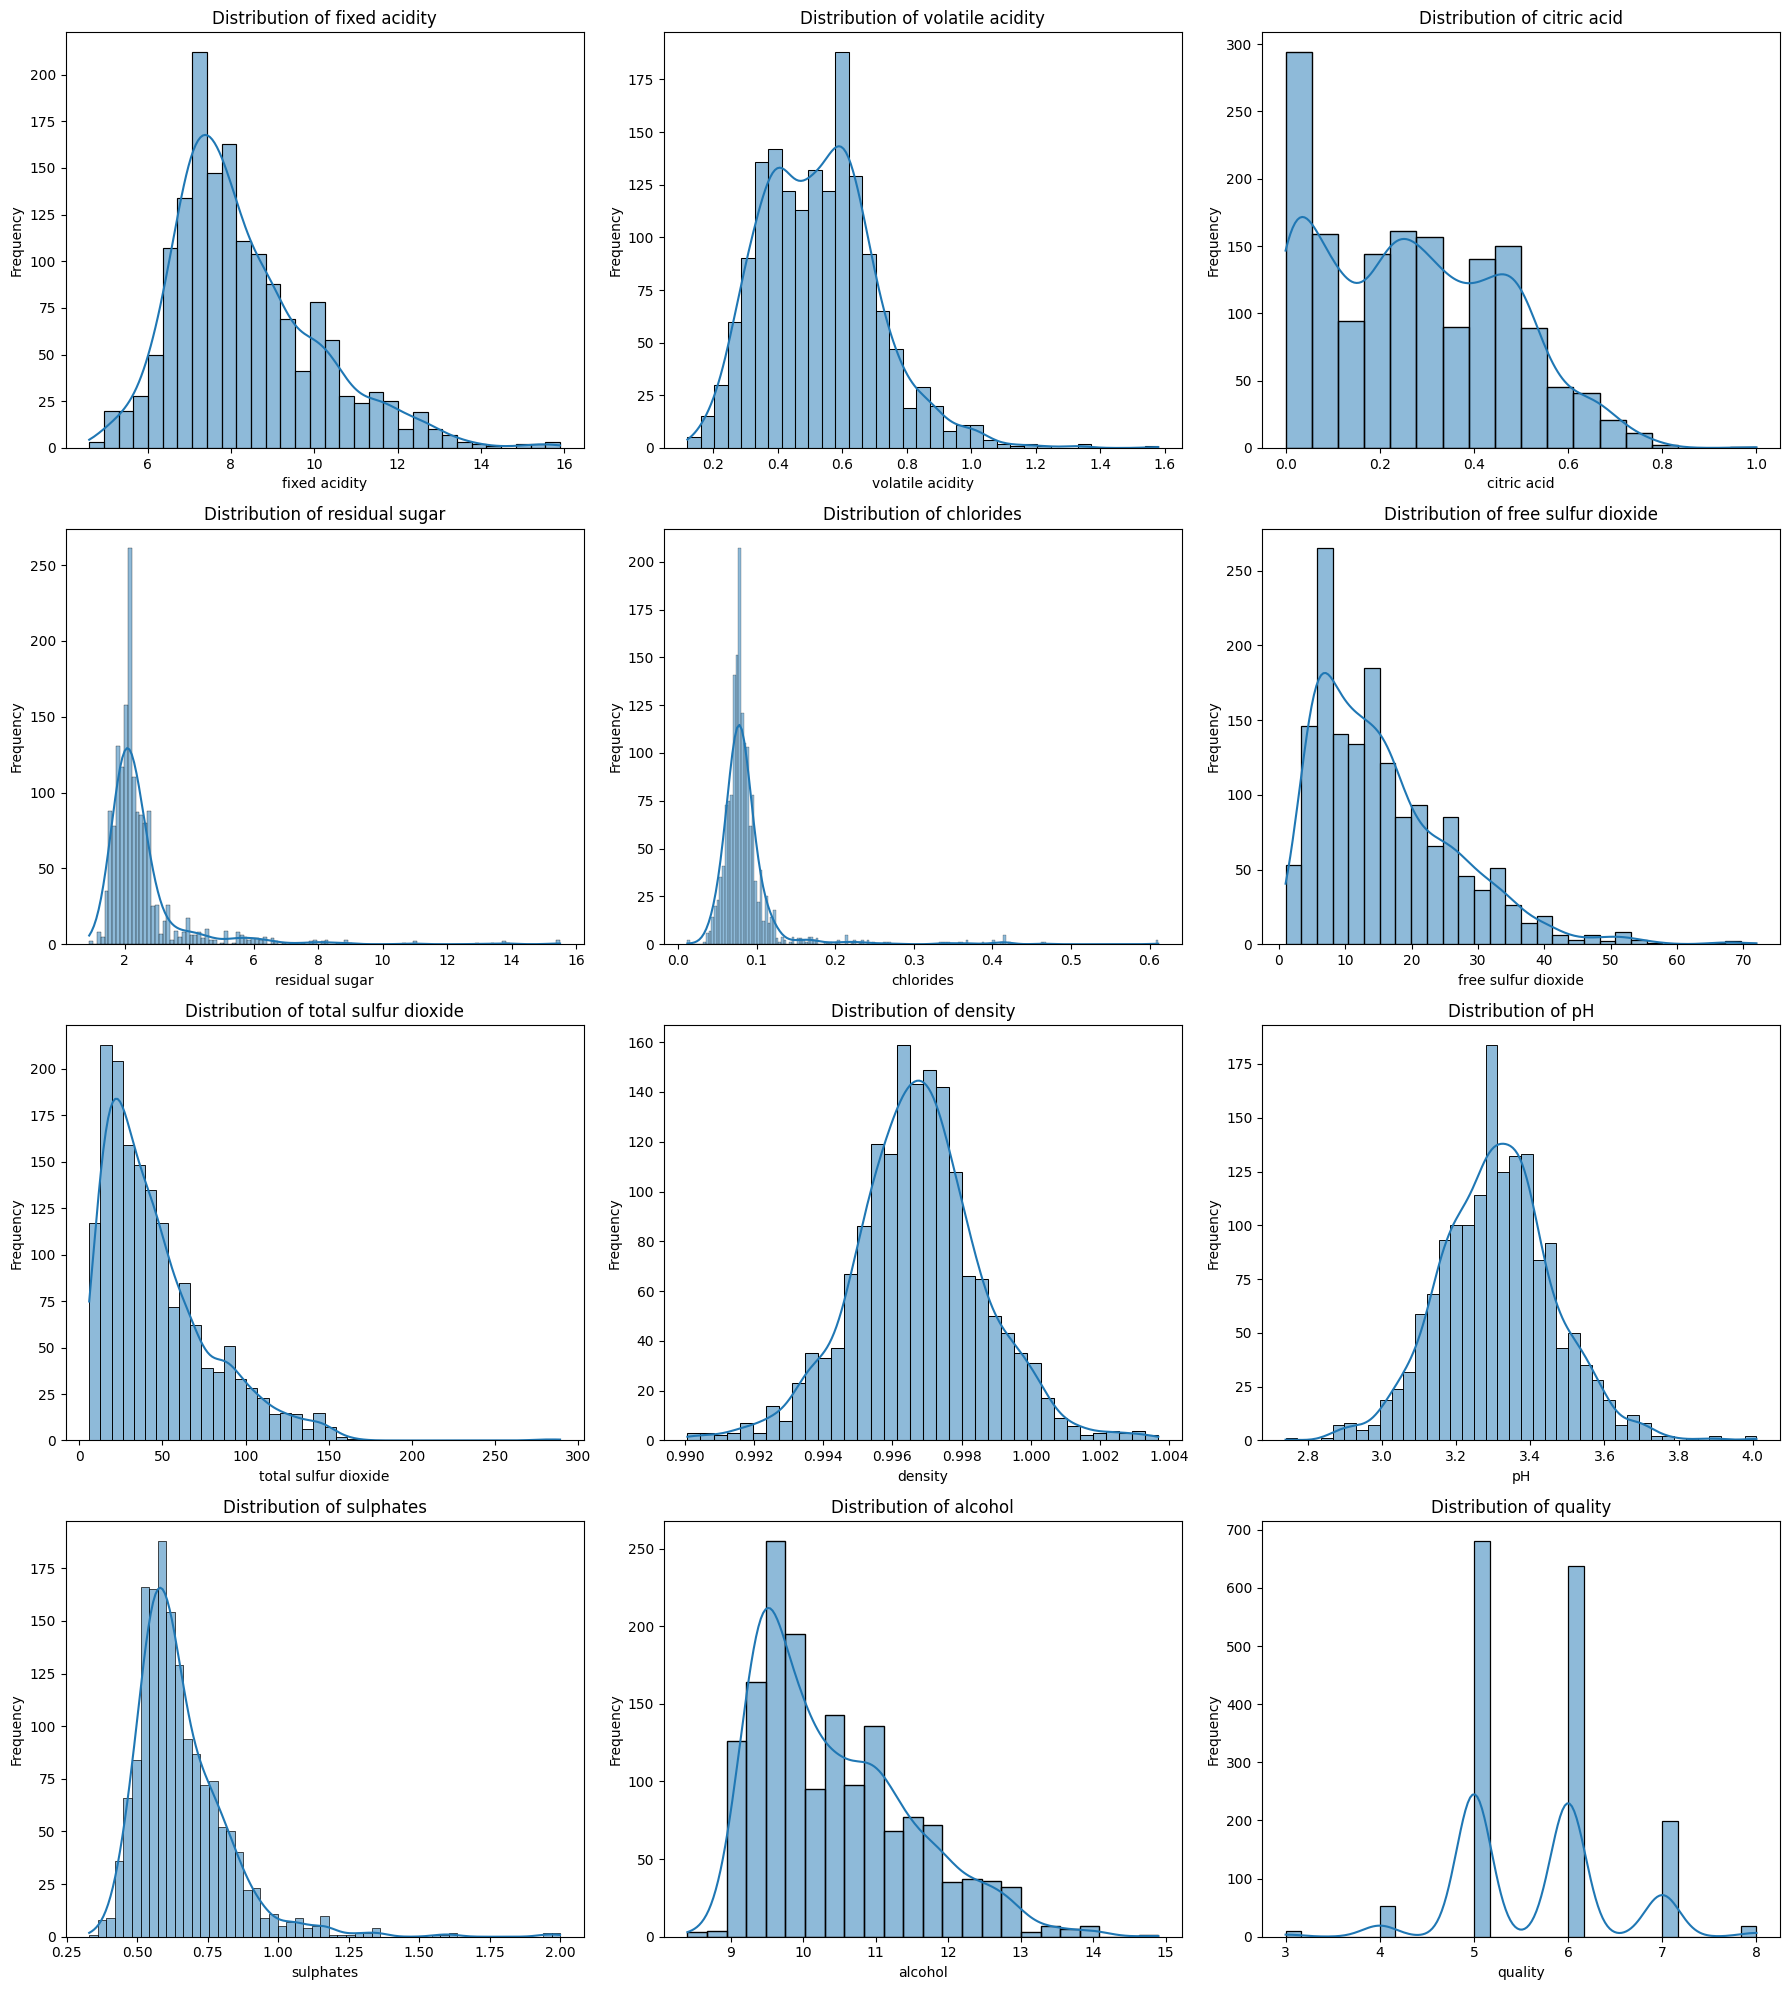

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_columns = data.shape[1]
num_rows = (num_columns + 2) // 3

plt.figure(figsize=(18, 5 * num_rows))

for i, column in enumerate(data.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(data[column], kde=True) # Use kde=True for kernel density estimate
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Test / Train Split

In [ ]:
# Определение признаков и целевой переменной
y = data['quality']  # Целевая переменная
X = data.drop('quality', axis=1)  # Признаки

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (1279, 11)
Shape of X_test: (320, 11)
Shape of y_train: (1279,)
Shape of y_test: (320,)


## Линейная модель

In [ ]:
import statsmodels.api as sm

# Добавление константы
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Линейная регрессия
model_ols = sm.OLS(y_train, X_train_sm).fit()
# print(model_ols.summary())

In [ ]:
ols_metrics = get_regression_metrics(model_ols, X_test_sm, y_test, 'Linear Regression')
ols_metrics

,model_nm,MSE,R2_Score,MAE
0,Linear Regression,0.39,0.4032,0.5035


In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Lasso с нормализацией
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])
lasso_pipeline.fit(X_train, y_train)

# Ridge с нормализацией
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)

lasso_metrics = get_regression_metrics(lasso_pipeline, X_test, y_test, 'Linear Regression, L1')
ridge_metrics = get_regression_metrics(ridge_pipeline, X_test, y_test, 'Linear Regression, L2')


In [ ]:
print(lasso_metrics)
print(ridge_metrics)

                model_nm     MSE  R2_Score     MAE
0  Linear Regression, L1  0.6572   -0.0056  0.6853
                model_nm   MSE  R2_Score     MAE
0  Linear Regression, L2  0.39    0.4032  0.5036


## Decision Tree (Решающее дерево)

### 🌳 Основные гиперпараметры дерева решений

#### 1. ⚙️ Параметры, регулирующие сложность модели:
- **`max_depth`**  – максимальная глубина дерева. Позволяет контролировать переобучение.
- **`min_samples_split`**  – минимальное количество образцов для разбиения узла. Предотвращает слишком глубокий рост дерева.
- **`min_samples_leaf`**  – минимальное количество образцов в листовом узле. Увеличение этого параметра делает модель более регуляризованной.
- **`max_leaf_nodes`**  – максимальное количество листовых узлов. Альтернативный способ ограничения глубины дерева.

#### 2. 📊 Критерий разбиения:
- **`criterion`** – функция оценки качества разбиения:
  - `gini`  (по умолчанию в `sklearn`) – критерий Джини (используется в задачах классификации).
  - `entropy`  – основан на энтропии (также для классификации).
  - `squared_error`  (для регрессии) – среднеквадратичная ошибка.

---

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='squared_error',
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_metrics = get_regression_metrics(dt_model, X_test, y_test, 'Decision Tree')
dt_metrics

,model_nm,MSE,R2_Score,MAE
0,Decision Tree,0.429,0.3435,0.51


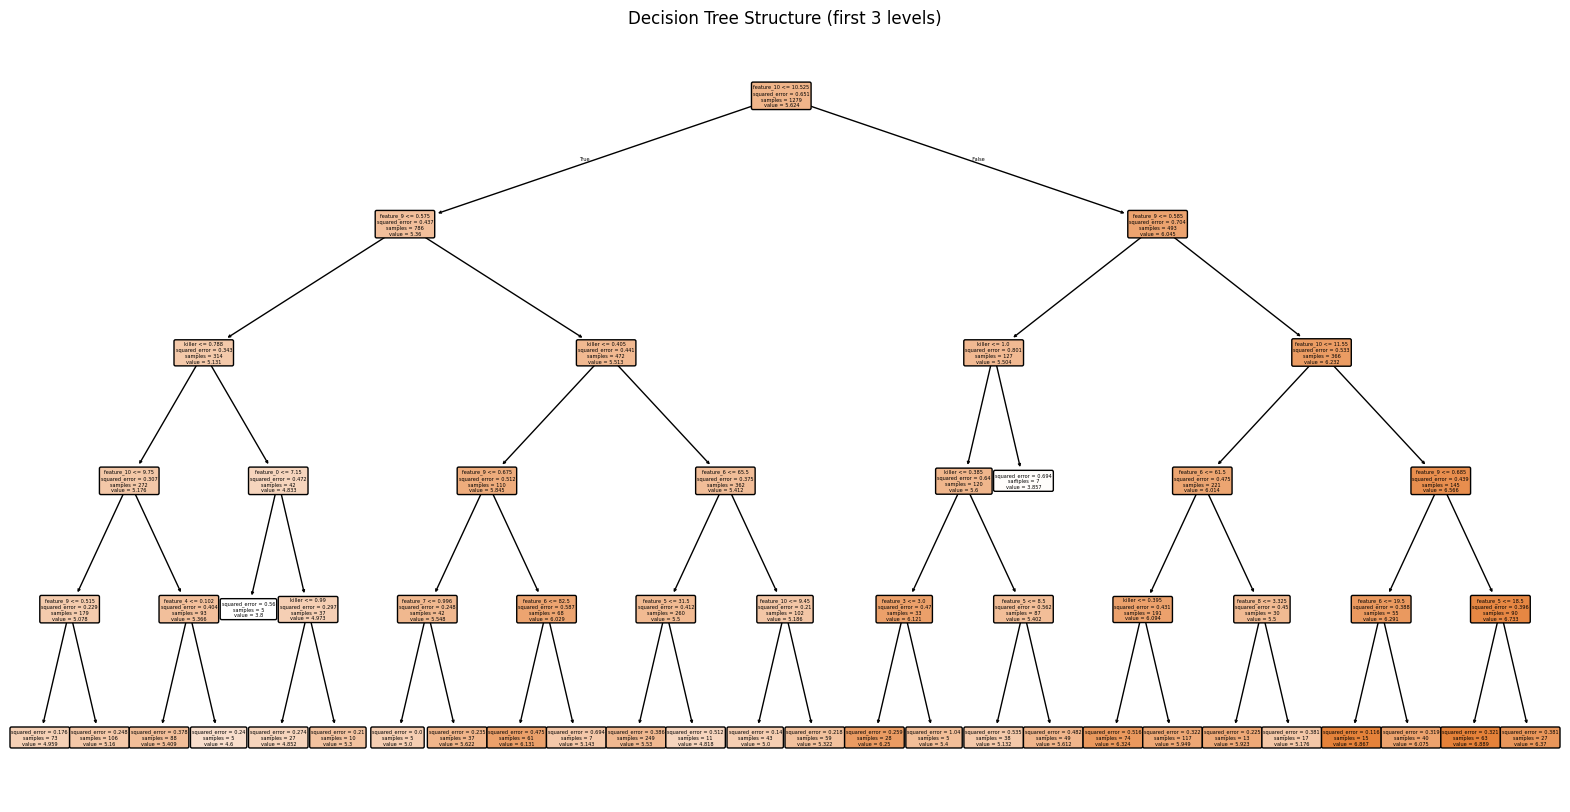

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns.tolist(), rounded=True, proportion=False)
plt.title('Decision Tree Structure (first 3 levels)')
plt.show()

## Random Forest (Случайный лес)

### 🌲🌲🌲 Основные гиперпараметры случайного леса

#### 🌳 **Количество деревьев**
- **`n_estimators`** – количество деревьев в лесу. (допустимые значения: [100, 5000])

#### 🎲 **Параметры для контроля случайности**
- **`bootstrap`** – если `True`, то используется случайная подвыборка с возвратом для обучения каждого дерева.  

#### ⚖️ **Режим обработки категориальных признаков**
- **`class_weight`** – вес классов, может быть полезен при наличии несбалансированных классов.  
    - Типичные значения: `None`, `balanced`, или словарь весов классов.  

---

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Initialize and train the Random Forest Regressor model w default params
rf_model = RandomForestRegressor(
    n_jobs=-1, # use all cpu's
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_metrics = get_regression_metrics(rf_model, X_test, y_test, 'Random Forest')
rf_metrics

,model_nm,MSE,R2_Score,MAE
0,Random Forest,0.3012,0.539,0.4224


Random Forest прекрасно параллелится на CPU (поведение по умолчанию; отвечает параметр n_jobs)



## Сравниваем качество моделей

In [ ]:
pd.concat([
    lasso_metrics,
    ridge_metrics,
    ols_metrics,
    dt_metrics,
    rf_metrics
], axis=0).sort_values(by='R2_Score', ascending=False)

,model_nm,MSE,R2_Score,MAE
0,Random Forest,0.3012,0.5390,0.4224
0,Linear Regression,0.3900,0.4032,0.5035
0,"Linear Regression, L2",0.3900,0.4032,0.5036
0,Decision Tree,0.4290,0.3435,0.5100
0,"Linear Regression, L1",0.6572,-0.0056,0.6853


# Bias and Variance decomposition

Как глубина дерева влияет на MSE, bias, variance?

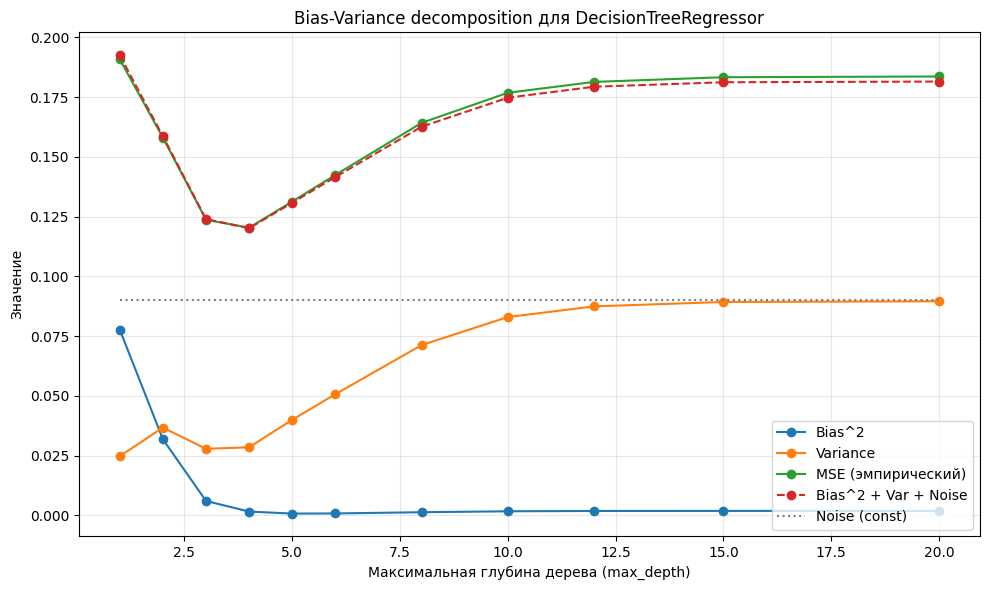

Средняя разница MSE - (bias^2 + variance + noise): 0.0008159222954822919
Максимальная по абсолютной величине разница: 0.0021248967762773074


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# 1) Истинная функция и шум
def f(x):
    return np.sin(2 * np.pi * x)

noise_sigma = 0.30
noise_var = noise_sigma**2

# 2) Параметры эксперимента
n_train = 150
n_test = 300
n_reps = 50
depths_grid = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

rng = np.random.default_rng(42)

# 3) Фиксируем тестовую сетку и истинные значения
X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
f_test = f(X_test.ravel())

# 4) Генерируем обучающие наборы и независимый шум для теста на каждую реплику
train_sets = []
eps_test = []
for rep in range(n_reps):
    X_train = rng.uniform(0, 1, size=(n_train, 1))
    y_train = f(X_train.ravel()) + rng.normal(0, noise_sigma, size=n_train)
    train_sets.append((X_train, y_train))
    eps_test.append(rng.normal(0, noise_sigma, size=n_test))  # для MSE против "шумных" целей

# 5) Эксперимент по глубинам дерева
bias2_list = []
var_list = []
noise_list = []
mse_direct_list = []
mse_decomp_list = []

for depth in depths_grid:
    preds = np.zeros((n_reps, n_test))
    mse_sum = 0.0

    for rep in range(n_reps):
        X_train, y_train = train_sets[rep]
        tree = DecisionTreeRegressor(
            max_depth=depth,
            random_state=rep  # влияет на разбиение при равенствах/случайных моментах
        )
        tree.fit(X_train, y_train)
        pred = tree.predict(X_test)
        preds[rep] = pred

        y_test_rep = f_test + eps_test[rep]
        mse_sum += np.mean((pred - y_test_rep) ** 2)

    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - f_test) ** 2)

    var = np.mean(np.var(preds, axis=0, ddof=0))

    noise = noise_var
    mse_direct = mse_sum / n_reps
    mse_decomp = bias2 + var + noise

    bias2_list.append(bias2)
    var_list.append(var)
    noise_list.append(noise)
    mse_direct_list.append(mse_direct)
    mse_decomp_list.append(mse_decomp)

# 6) Визуализация
plt.figure(figsize=(10, 6))
plt.plot(depths_grid, bias2_list, marker='o', label='Bias^2')
plt.plot(depths_grid, var_list, marker='o', label='Variance')
plt.plot(depths_grid, mse_direct_list, marker='o', label='MSE (эмпирический)')
plt.plot(depths_grid, mse_decomp_list, marker='o', linestyle='--', label='Bias^2 + Var + Noise')
plt.hlines(noise_var, xmin=min(depths_grid), xmax=max(depths_grid), colors='gray', linestyles='dotted', label='Noise (const)')

plt.xlabel('Максимальная глубина дерева (max_depth)')
plt.ylabel('Значение')
plt.title('Bias-Variance decomposition для DecisionTreeRegressor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7) Проверка разложения
diff = np.array(mse_direct_list) - np.array(mse_decomp_list)
print("Средняя разница MSE - (bias^2 + variance + noise):", np.mean(diff))
print("Максимальная по абсолютной величине разница:", np.max(np.abs(diff)))

Как число деревьев в Random Forest влияет на MSE, bias, variance?

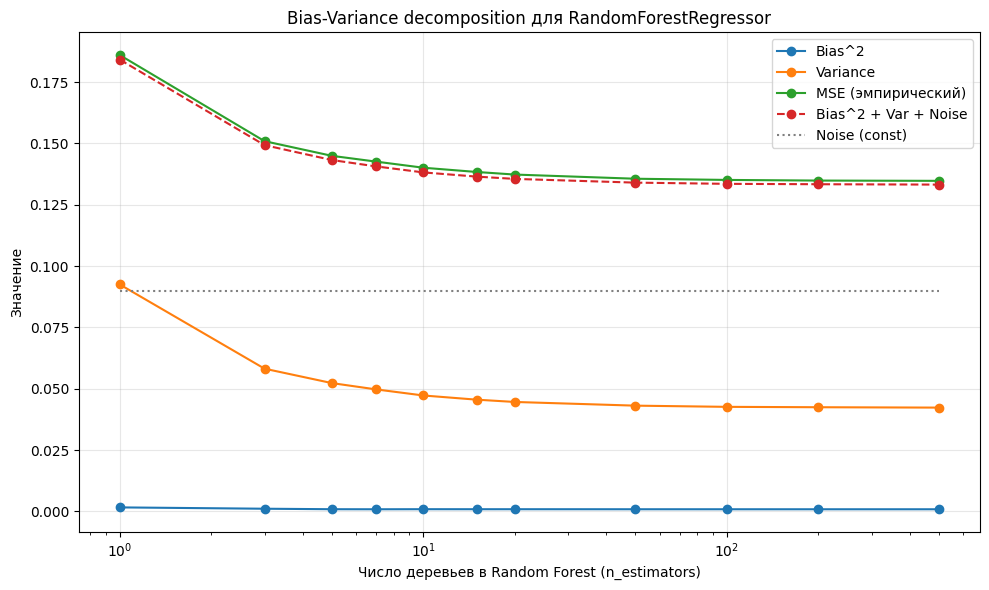

Средняя разница MSE - (bias^2 + variance + noise): 0.001719491717275716
Максимальная по абсолютной величине разница: 0.001947966885136626


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1) Зададим истинную функцию и уровень шума
def f(x):
    # Гладкая нелинейная зависимость
    return np.sin(2 * np.pi * x)

noise_sigma = 0.30  # стандартное отклонение шума
noise_var = noise_sigma**2

# 2) Параметры эксперимента
n_train = 150          # размер обучающей выборки на каждую реплику
n_test = 300           # размер тестовой сетки (фиксируем)
n_reps = 50            # число реплик (сколько раз переобучаем модели)
trees_grid = [1, 3, 5, 7, 10, 15, 20, 50, 100, 200, 500]  # числа деревьев в лесу

rng = np.random.default_rng(42)

# 3) Фиксируем тестовую сетку и истинные значения на ней
X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
f_test = f(X_test.ravel())

# 4) Заранее сгенерируем обучающие наборы и независимый шум для теста для каждой реплики
train_sets = []
eps_test = []
for rep in range(n_reps):
    X_train = rng.uniform(0, 1, size=(n_train, 1))
    y_train = f(X_train.ravel()) + rng.normal(0, noise_sigma, size=n_train)
    train_sets.append((X_train, y_train))
    eps_test.append(rng.normal(0, noise_sigma, size=n_test))  # для оценки MSE на "шумных" таргетах

# 5) Запускаем эксперименты по числу деревьев
bias2_list = []
var_list = []
noise_list = []
mse_direct_list = []       # MSE против шумных y_test
mse_decomp_list = []       # bias^2 + var + noise

for n_trees in trees_grid:
    # Собираем предсказания всех реплик для данного числа деревьев
    preds = np.zeros((n_reps, n_test))
    mse_sum = 0.0

    for rep in range(n_reps):
        X_train, y_train = train_sets[rep]
        rf = RandomForestRegressor(
            n_estimators=n_trees,
            random_state=rep,    # фиксируем seed для воспроизводимости
            n_jobs=-1,
            bootstrap=True
        )
        rf.fit(X_train, y_train)
        pred = rf.predict(X_test)
        preds[rep] = pred

        # "шумные" целевые значения на тесте для этой реплики
        y_test_rep = f_test + eps_test[rep]
        mse_sum += np.mean((pred - y_test_rep) ** 2)

    # Оценки bias^2, variance, noise на тестовой сетке
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - f_test) ** 2)
    var = np.mean(np.var(preds, axis=0, ddof=0))
    noise = noise_var

    # Прямой MSE (усреднённый по репликам) и MSE через разложение
    mse_direct = mse_sum / n_reps
    mse_decomp = bias2 + var + noise

    bias2_list.append(bias2)
    var_list.append(var)
    noise_list.append(noise)
    mse_direct_list.append(mse_direct)
    mse_decomp_list.append(mse_decomp)

# 6) Визуализация
plt.figure(figsize=(10, 6))
plt.plot(trees_grid, bias2_list, marker='o', label='Bias^2')
plt.plot(trees_grid, var_list, marker='o', label='Variance')
plt.plot(trees_grid, mse_direct_list, marker='o', label='MSE (эмпирический)')
plt.plot(trees_grid, mse_decomp_list, marker='o', linestyle='--', label='Bias^2 + Var + Noise')
plt.hlines(noise_var, xmin=min(trees_grid), xmax=max(trees_grid), colors='gray', linestyles='dotted', label='Noise (const)')

plt.xscale('log')  # удобно смотреть тренд по лог-шкале
plt.xlabel('Число деревьев в Random Forest (n_estimators)')
plt.ylabel('Значение')
plt.title('Bias-Variance decomposition для RandomForestRegressor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7) Небольшая проверка: насколько близко MSE к bias^2 + variance + noise
diff = np.array(mse_direct_list) - np.array(mse_decomp_list)
print("Средняя разница MSE - (bias^2 + variance + noise):", np.mean(diff))
print("Максимальная по абсолютной величине разница:", np.max(np.abs(diff)))

## Когда Decision Tree лучше, чем Random Forest ?

In [ ]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n_features = 500
n_samples = 2000
data = make_classification(
    n_samples=n_samples,
    n_informative=2,
    n_features=n_features,
    random_state = 42,
    n_redundant = n_features - n_features // 4
)
df = pd.DataFrame(data[0], columns = [f'feature_{k}' for k in range(n_features)])
df['target'] = data[1]
df['feature_1'] = df['target'] + 0.5* df['feature_1']
df.rename(columns={'feature_1':'killer'}, inplace = True)
df.head(10)

,feature_0,killer,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_491,feature_492,feature_493,feature_494,feature_495,feature_496,feature_497,feature_498,feature_499,target
0,-1.025061,-0.474793,-1.141729,0.348795,-0.451330,0.424443,2.070620,1.079577,0.633513,-0.403116,...,-1.067851,0.887948,0.180787,-0.356906,1.272190,-0.523223,-0.498193,1.036595,-0.626309,0
1,-0.614004,1.790212,-0.249593,0.547996,0.154448,1.229019,-0.633930,-1.322448,1.140994,-0.178206,...,0.933795,-0.613306,1.410173,0.994926,0.919166,-0.847387,-0.289241,-1.013821,-0.087843,1
2,0.250921,1.710774,-1.672573,0.102218,0.190139,0.435420,-0.161576,-1.353717,0.266255,0.133676,...,-0.341199,-0.850954,0.676041,0.756111,-0.224477,-0.167358,0.127026,-1.158197,0.312273,1
3,-0.714894,1.582687,-0.998259,0.531590,-1.612839,1.124936,-0.694706,-0.921553,1.089398,-0.227348,...,1.064742,-0.354557,1.233164,0.778938,1.020867,-0.818984,-0.339648,-0.667189,-0.192477,1
4,1.245366,0.950996,0.101276,-0.621229,-0.214617,-1.083364,0.890790,-0.164816,-1.213169,0.452914,...,1.481147,-0.411847,-0.977842,-0.270326,-1.637121,0.946657,0.599923,-0.307331,0.593589,1
5,1.185974,-0.596491,-0.061214,-0.765087,-0.446936,-1.530444,-1.156207,0.850538,-1.544946,0.398948,...,-2.844653,0.193726,-1.597316,-0.875870,-1.639443,1.174721,0.566619,0.543738,0.418277,0
6,0.011905,-0.206652,-0.413297,-0.070995,0.502364,-0.197386,-0.626281,0.376234,-0.157709,-0.007808,...,-1.085955,0.215787,-0.259138,-0.234498,-0.045798,0.111503,0.003975,0.310716,-0.049452,0
7,0.878549,1.611380,-2.431939,-0.234432,-0.491156,-0.178321,0.764706,-1.299905,-0.398081,0.357534,...,1.436025,-0.978910,0.092743,0.535857,-1.060460,0.346846,0.428732,-1.199451,0.591453,1
8,0.061500,-1.045330,-0.638641,-0.359746,0.388522,-0.999525,0.163325,1.902882,-0.798970,-0.039025,...,-0.713770,1.091061,-1.311767,-1.186405,-0.233344,0.564977,0.020724,1.571335,-0.249523,0
9,-2.055526,0.759051,1.937964,1.239343,1.482013,2.403302,0.190029,-0.970633,2.482968,-0.707631,...,1.311940,-0.042934,2.435561,1.208979,2.801297,-1.899479,-0.984407,-0.524390,-0.798424,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
print_classification_metrics(dt, X_test, y_test, 'Decision Tree')
print_classification_metrics(rf, X_test, y_test, 'Random Forest')

Metrics for Decision Tree:
Accuracy: 0.9909
Precision: 0.994
Recall: 0.988
AUC: 0.9909
Confusion_Matrix: [[325, 2], [4, 329]]


Metrics for Random Forest:
Accuracy: 0.95
Precision: 0.9518
Recall: 0.9489
AUC: 0.9907
Confusion_Matrix: [[311, 16], [17, 316]]




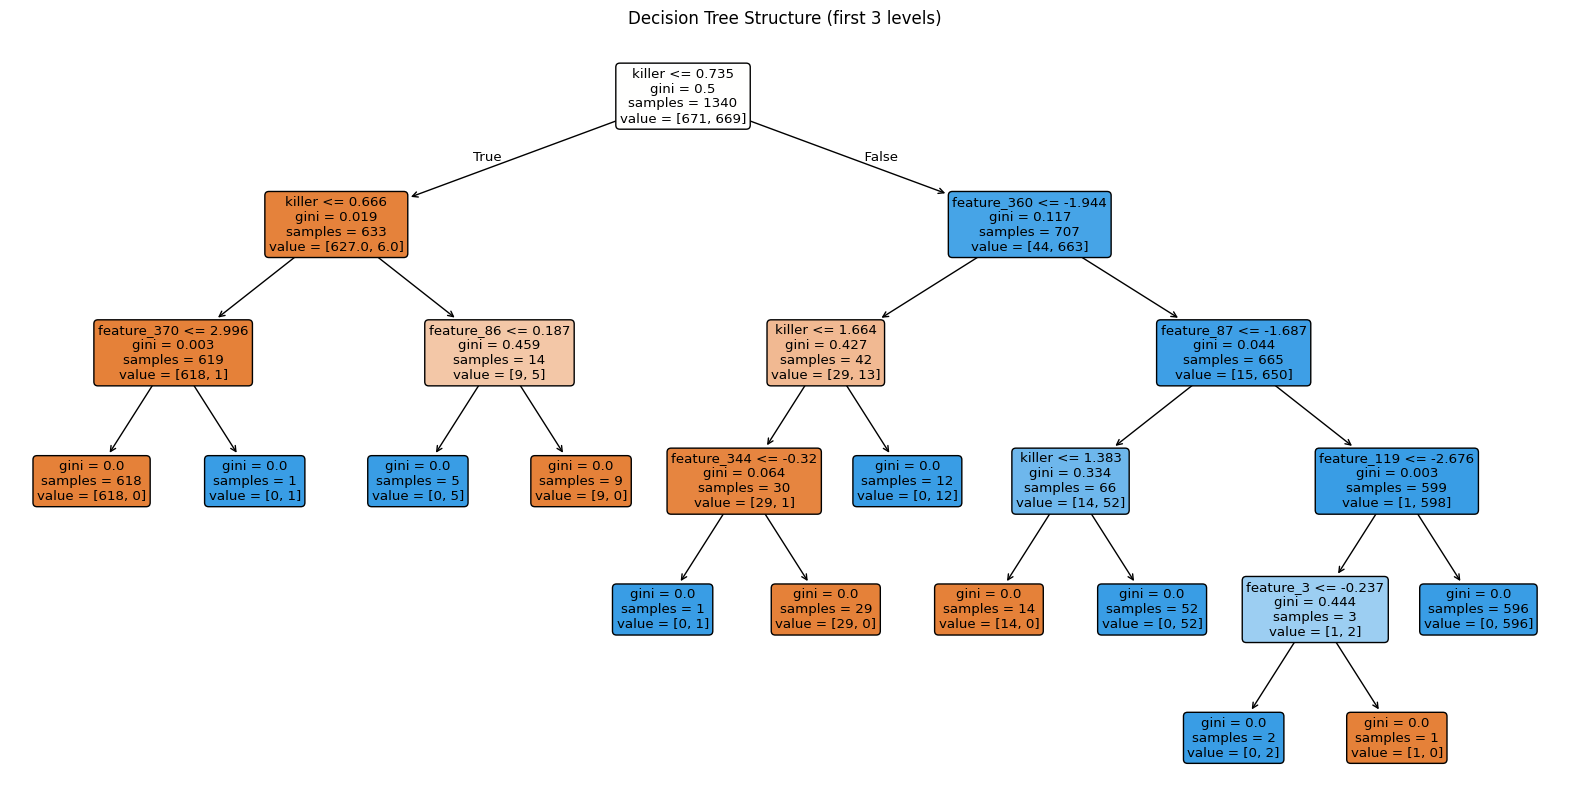

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True, feature_names=X_test.columns.tolist(), rounded=True, proportion=False)
plt.title('Decision Tree Structure (first 3 levels)')
plt.show()

Subspacing в RF не всегда может дать преимущество.